# Building a Risk-Based Lending Framework: Predicting Borrower Default to Support Credit Decisions

## Problem Definition & Business Context



### Business Objective

Lending institutions face a critical challenge: approving loans profitably while controlling default risk. In an uncertain lending environment, the ability to accurately predict which borrowers will default is a key competitive advantage. This project builds an interpretable credit risk modeling pipeline that quantifies the drivers of default, predicts individual borrower-level risk, and operationalizes these predictions into a practical risk-based decision framework.

Default prediction matters because it directly impacts institutional viability. For a lender, every undetected defaulter erodes the portfolio's profitability, while overly conservative lending strangles revenue growth. This project addresses that tension by enabling data-driven approval decisions grounded in quantified risk rather than rules of thumb or subjective judgment.

### Stakeholders

This work serves multiple stakeholders with distinct needs:

- **Risk Management Teams**: Need transparent, audit-friendly models that explain *why* a borrower is flagged as high-risk, enabling proactive portfolio monitoring and stress testing.
- **Credit Decision Makers**: Require fast, actionable predictions at the point of origination to inform approve/deny/conditional approval decisions.
- **Executive Leadership**: Seek empirical evidence that lending policies are optimized—balancing approval rates, expected loss, and portfolio quality to maximize shareholder value.
- **Regulators & Compliance**: Require models free from prohibited bias and with documented validation, making interpretability non-negotiable.

### Success Criteria

Success is measured across three dimensions:

1. **Predictive Accuracy**: The model must discriminate between defaulters and non-defaulters with high ROC-AUC (target: >0.75) and calibrated probability estimates, enabling reliable risk ranking.

2. **Interpretability**: Feature importance, SHAP values, and partial dependence plots must reveal *actionable* insights—e.g., "debt-to-income ratio above X% doubles default risk"—so stakeholders understand and trust model decisions.

3. **Operational Feasibility**: Predictions must integrate into existing loan approval workflows with minimal latency, and the decision framework must be implementable by credit teams with clear decision thresholds and risk tiers.

### Problem Framing

The core task is a **supervised binary classification problem**: given historical loan data (borrower characteristics, loan terms, economic conditions), predict the probability that a loan will default within a defined period (typically 24–36 months).

Key constraints:
- **Class imbalance**: Defaults are rare (typically 2–5% of loans), requiring careful threshold tuning and evaluation metrics beyond accuracy.
- **Interpretability vs. predictive power**: Complex models (neural networks, gradient boosting) may outperform logistic regression, but credit decisions must be explainable to borrowers and regulators.
- **Data quality**: Historical data may contain missing values, coding errors, or samples from a different economic regime, requiring rigorous preprocessing and validation.

The deliverable is a production-ready pipeline that ingests applicant profiles, outputs a risk score (0–100) and predicted default probability, and recommends an approval decision tier.

## Data Understanding and Exploration


#### Load Libraries

In [1]:
# ===============================
# Standard Library
# ===============================
import os
import re
import warnings
from pathlib import Path
from typing import Dict, Tuple, Any
import logging

# ===============================
# Data Manipulation
# ===============================
import pandas as pd
import numpy as np

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ===============================
# Scikit-Learn
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# ===============================
# Settings
# ===============================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Converts Scientific Notation to rational number. 
#pd.options.display.float_format = '{:,.2f}'.format # Toggle Comments to implement or not

# --- Global styling ---
sns.set_theme(
    style="whitegrid",     # clean background
    context="talk",        # larger readable fonts
    palette="deep"
)

# Configure logging for audit trail
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)

#### Functions

In [2]:
# Outlier Check Function
def iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] < lower) | (df[column] > upper)]

In [3]:
# Currency Conversion Fucntion
def currency_to_float(series):
    return (
        series
        .str.replace(r'[^\d.]', '', regex=True)
        .pipe(pd.to_numeric, errors='coerce')
    )

In [4]:
# Function for making aesthetic plots
def plot_professional_default_rate(df, feature, title=None):
    # Calculate rates
    summary = df.groupby(feature)["Current_loan_status"].value_counts(normalize=True).unstack()["DEFAULT"]
    summary = summary.sort_values(ascending=False)
    
    # 1. Setup Figure
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    # 2. Use a sophisticated color palette (e.g., 'mako' or custom hex)
    colors = ['#1a434e' if (x < summary.max()) else '#e74c3c' for x in summary]
    
    sns.barplot(x=summary.index, y=summary.values, palette=colors, ax=ax)
    
    # 3. Enhance Typography and Labels
    ax.set_title(title or f"Default Risk by {feature.replace('_', ' ').title()}", 
                 fontsize=18, pad=20, fontweight='bold', loc='left')
    ax.set_ylabel("Probability of Default", fontsize=12, fontweight='bold')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    
    # 4. Format Y-axis as Percentage
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # 5. Remove "Chart Junk" (Spines)
    sns.despine(left=True, bottom=False)
    
    # 6. Add Data Labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [5]:
def plot_target_distribution(df, target_col):
    """Professional plot for the Target Variable distribution."""
    counts = df[target_col].value_counts(normalize=True)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#1a434e', '#e74c3c'] # Professional Navy and Risk Red
    
    sns.barplot(x=counts.index, y=counts.values, palette=colors, ax=ax)
    
    # Labeling
    ax.set_title("Target Variable Distribution (Class Balance)", fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel("Proportion of Portfolio", fontsize=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Add percentage labels on top
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    sns.despine()
    plt.show()


In [6]:
def plot_professional_boxplot(df, column, title=None, xlabel=None, ylabel=None, divisor=1, is_currency=False):
    """
    Modular professional boxplot.
    divisor: set to 1000 to scale raw data to 'k'.
    is_currency: set to True to format as Euro with 'k' suffix.
    """
    fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
    brand_navy = '#1a434e'
    
    # Scaling logic
    plot_data = df[column] / divisor
    
    # Create Boxplot
    sns.boxplot(
        x=plot_data,
        ax=ax,
        color=brand_navy,
        width=0.5,
        fliersize=4,
        linewidth=1.5,
        boxprops=dict(alpha=0.85, edgecolor='black'),
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(markerfacecolor='#e74c3c', markeredgecolor='none', alpha=0.4)
    )
    
    # Labels
    clean_name = column.replace('_', ' ').title()
    ax.set_title(title or f"Distribution of {clean_name}", 
                 fontsize=18, pad=20, fontweight='bold', loc='left')
    ax.set_xlabel(xlabel or clean_name, fontsize=12, fontweight='bold')
    
    # Formatting Logic
    if is_currency:
        # Formats as €Valuek (e.g., €50k)
        fmt = '€{x:,.0f}k' 
        ax.xaxis.set_major_formatter(mtick.StrMethodFormatter(fmt))
    else:
        # Standard number formatting with commas
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    sns.despine(left=True)
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

In [7]:
def plot_professional_ecdf(df, column, title=None, xlabel=None, log_scale=False, divisor=1, is_currency=False):
    """
    Creates a premium eCDF plot with optional log scaling and custom formatting.
    """
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    brand_navy = '#1a434e'
    
    # 1. Scaling logic for the data
    plot_data = df[column] / divisor
    
    # 2. Plot the eCDF
    sns.ecdfplot(
        data=plot_data,
        ax=ax,
        color=brand_navy,
        linewidth=2.5
    )
    
    # 3. Add the "Premium" Fill
    line = ax.get_lines()[0]
    x, y = line.get_data()
    ax.fill_between(x, y, color=brand_navy, alpha=0.1)
    
    # 4. Handle Log Scale
    if log_scale:
        ax.set_xscale('log')
    
    # 5. Enhance Typography and Labels
    clean_name = column.replace('_', ' ').title()
    ax.set_title(title or f"Empirical Cumulative Distribution of {clean_name}", 
                 fontsize=18, pad=20, fontweight='bold', loc='left')
    ax.set_ylabel("Cumulative Probability", fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel or clean_name, fontsize=12, fontweight='bold')
    
    # 6. Formatting Logic (Euro + k)
    if is_currency:
        fmt = '€{x:,.0f}k' 
        ax.xaxis.set_major_formatter(mtick.StrMethodFormatter(fmt))
    elif not log_scale:
        # Standard formatting (Log scales usually handle their own formatting better)
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # 7. Remove Chart Junk
    sns.despine()
    
    plt.tight_layout()
    plt.show()

In [8]:
def plot_professional_histogram(df, column, title=None, xlabel=None, bins=20, kde=True):
    """
    Creates a professional histogram matching the notebook's visual style.
    
    Parameters:
    - df: The dataframe.
    - column: The column to plot.
    - title: Custom title.
    - xlabel: Custom x-axis label.
    - bins: Number of bins for the histogram.
    - kde: Boolean, whether to plot the Kernel Density Estimate line.
    """
    # 1. Setup Figure
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    brand_navy = '#1a434e'
    
    # 2. Create Histogram
    sns.histplot(
        data=df[column],
        bins=bins,
        kde=kde,
        color=brand_navy,
        ax=ax,
        edgecolor='white',
        linewidth=1.2,
        alpha=0.8
    )
    
    # 3. Enhance Typography and Labels
    clean_name = column.replace('_', ' ').title()
    ax.set_title(title or f"Distribution of {clean_name}", 
                 fontsize=18, pad=20, fontweight='bold', loc='left')
    ax.set_xlabel(xlabel or clean_name, fontsize=12, fontweight='bold')
    ax.set_ylabel("Frequency", fontsize=12, fontweight='bold')
    
    # 4. Format X-axis with commas for readability
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # 5. Remove Chart Junk
    sns.despine()
    
    plt.tight_layout()
    plt.show()



#### Load dataset

SOURCE:  This analysis uses publicly available loan data sourced from Kaggle 
(https://www.kaggle.com/datasets/prakashraushan/loan-dataset).

While the dataset is publicly available, this project **simulates a realistic credit risk 
scenario** that mirrors production lending environments:

**Dataset Justification**: While anonymized/synthetic, the dataset contains realistic 
lending variables (income, employment history, credit history, loan purpose, outcomes) 
that mirror actual loan origination data. This allows demonstration of production-grade 
data science practices without requiring proprietary banking data.


In [9]:
def find_repo_root(start_path: Path) -> Path:
    """
    Walk upward from start_path until a folder containing .git is found.
    """
    for path in [start_path, *start_path.parents]:
        if (path / ".git").exists():
            return path
    raise RuntimeError("Repo root not found. Are you inside the project?")

# Find repository root dynamically
PROJECT_ROOT = find_repo_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data-science-toolbox" / "datasets" / "raw" / "Loan_Dataset"

data = pd.read_csv(DATA_DIR / "LoanDataset.csv")
data.head(3) # Simple confirmation that data loaded. 

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT


#### Basic preliminary checks

**Structure**
- **Observations**: 32,586 loan accounts
- **Features**: 13 variables
- **Target Variable**: `Current_loan_status` (DEFAULT / NO DEFAULT)
- **Time Period**: Cross-sectional point-in-time data (vintage not specified)

**Features**
| Feature | Type | Description |
|---------|------|-------------|
| `customer_id` | Identifier | Unique customer identifier |
| `customer_age` | Numeric | Age of customer (years) |
| `customer_income` | Numeric | Annual income ($) |
| `home_ownership` | Categorical | Status (RENT, OWN, MORTGAGE) |
| `employment_duration` | Numeric | Employment tenure (months) |
| `loan_intent` | Categorical | Loan purpose (PERSONAL, EDUCATION, MEDICAL, VENTURE, HOME, DEBT_CONSOLIDATION) |
| `loan_grade` | Categorical | Credit risk grade assigned (A-G) |
| `loan_amnt` | Numeric | Loan amount requested ($) |
| `loan_int_rate` | Numeric | Interest rate (%) |
| `term_years` | Numeric | Loan term (years) |
| `historical_default` | Binary | Prior default history (Y/N) |
| `cred_hist_length` | Numeric | Credit history length (years) |
| `Current_loan_status` | Binary | Target: DEFAULT / NO DEFAULT |

In [10]:
# Compute Data shape and memory size. 
data_shape = data.shape
data_storage_size = data.memory_usage(deep=True).sum()
print(f'The dataset contains {data_shape[0]} rows and {data_shape[1]} columns.  \nThe dataset takes up approximately {data_storage_size / 1e6:.2f} MB of memory.')

The dataset contains 32586 rows and 13 columns.  
The dataset takes up approximately 14.24 MB of memory.


In [11]:
data.describe(include='all')

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
count,32583.000000,32586.000000,32586,32586,31691.000000,32586,32586,32585,29470.000000,32586.000000,11849,32586.000000,32582
unique,NaN,NaN,4299,4,NaN,6,5,755,NaN,NaN,2,NaN,2
top,NaN,NaN,60000,RENT,NaN,EDUCATION,A,"£10,000.00",NaN,NaN,Y,NaN,NO DEFAULT
freq,NaN,NaN,1046,16451,NaN,6454,15661,2664,NaN,NaN,6128,NaN,25742
mean,16289.497806,27.732769,NaN,NaN,4.790161,NaN,NaN,NaN,11.011553,4.761738,NaN,5.804026,NaN
std,9405.919628,6.360528,NaN,NaN,4.142746,NaN,NaN,NaN,3.240440,2.471107,NaN,4.055078,NaN
min,1.000000,3.000000,NaN,NaN,0.000000,NaN,NaN,NaN,5.420000,1.000000,NaN,2.000000,NaN
25%,8144.500000,23.000000,NaN,NaN,2.000000,NaN,NaN,NaN,7.900000,3.000000,NaN,3.000000,NaN
50%,16288.000000,26.000000,NaN,NaN,4.000000,NaN,NaN,NaN,10.990000,4.000000,NaN,4.000000,NaN
75%,24433.500000,30.000000,NaN,NaN,7.000000,NaN,NaN,NaN,13.470000,7.000000,NaN,8.000000,NaN


In [12]:
# Disregard memory usage under .info.  It does not take in account for the memory used by string/object data. 
# The above calculation is more accurate for understanding the memory footprint of the dataset.
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  str    
 3   home_ownership       32586 non-null  str    
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  str    
 6   loan_grade           32586 non-null  str    
 7   loan_amnt            32585 non-null  str    
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  str    
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  str    
dtypes: float64(3), int64(3), str(7)
memory usage: 3.2 MB
None


In [13]:
data.isna().sum()

customer_id                3
customer_age               0
customer_income            0
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20737
cred_hist_length           0
Current_loan_status        4
dtype: int64

#### Preliminary Data Quality Assessment

**Initial Findings:**
A preliminary review of the raw data reveals the following data quality issues that 
require correction before modeling:

**1. Missing Values**
- Multiple features contain NaN values that prevent accurate summary statistics
- Distribution of missingness varies by feature and requires investigation
- **Impact**: Cannot compute reliable means, medians, or distributions in current state

**2. Implausible Values**
- **customer_age**: Range from 3 to 144 years (typical lending age: 18-80)
- **employment_duration**: Values of 0 months and 123+ months (atypical)
- **customer_id**: Stored as float rather than categorical ID (unusual)
- **Impact**: Outliers could bias models and suggest data entry errors

**3. Domain-Specific Inconsistencies**
These values violate lending industry norms and require investigation:

- **Loan amounts vs. loan intent**: 
  - Home loans with amounts < €10,000 (unusually low)
  - Personal loans with amounts > €500,000 (unusually high)
  
- **Interest rates by loan type**:
  - Student loan rates < mortgage rates (inverted from market norms)
  - Venture loan rates inconsistent with business lending standards
  
- **Income to loan ratio**:
  - Mortgages where loan amount > 10x annual income (risk assessment concern)
  - Personal loans with suspicious income-to-loan relationships

**4. Multicollinearity Concerns**
Preliminary observation of feature correlations suggests:
- Strong relationship between `customer_income` and `loan_amnt` (especially mortgages)
- Potential correlation between `employment_duration` and `cred_hist_length`
- `loan_grade` likely highly correlated with `loan_int_rate`
- **Impact**: May cause model instability and inflation of feature importance estimates


## Data Cleaning & Feature Engineering



Section 3: DATA CLEANING & PREPARATION PIPELINE
├── 3.1 Duplicate Handling
│   ├── Define duplicate strategy (exact rows, customer-level)
│   ├── Execute removal
│   └── Log audit trail (rows removed, validation)
├── 3.2 Missing Data Strategy
│   ├── Analyze missingness patterns (BEFORE imputing)
│   ├── Create missing indicators if informative
│   ├── Execute imputation (informed by analysis)
│   └── Audit log (missing % before/after, method used)
├── 3.3 Outlier Handling
│   ├── Define outlier thresholds (domain + statistical)
│   ├── Execute treatment (cap, remove, transform)
│   └── Audit log (outliers found/handled)
├── 3.4 Data Type Corrections
│   ├── Fix data type mismatches
│   ├── Convert strings to numeric/datetime as needed
│   └── Validation (confirm conversions successful)
├── 3.5 Value Corrections
│   ├── Handle impossible values (negative ages, etc.)
│   ├── Standardize formats (phone numbers, dates)
│   └── Audit log (corrections made)
└── 3.6 Pipeline Validation & Documentation
    ├── Confirm all cleaning steps succeeded
    ├── Document rows removed at each step
    ├── Verify no unintended side effects
    └── Summary: Input X rows → Output Y rows



#### Drop duplicates, features, then missing values

##### Duplicates

The `customer_id` has one last use before we drop it from our table--duplication verification.  Dataset integrity was evaluated using both entity-level (customer_id) and record-level duplication checks. Six customer IDs appeared multiple times in the dataset; however, inspection revealed that each duplicated pair contained identical values across all features and the target variable.

These records therefore represent data duplication rather than multiple loan applications. To prevent artificial inflation of sample size and bias in downstream statistical analysis and model training, duplicate rows were removed, retaining a single instance of each observation.

After removing the duplicates, the `customer_id` column was purged from our table.  Missing values were handled with care, feature-by-feature.  A brief description of what the decisioning was can be found in the code chunk notes in each cell.

In [14]:
# ==============================================================================
# DUPLICATE HANDLING CONFIGURATION
# ==============================================================================

DUPLICATE_CONFIG = {
    'check_exact_rows': True,
    'check_customer_level': True,
    'customer_id_column': 'customer_id',
    'keep': 'first',
    'fail_if_duplicates_remain': True,
    'subset': None,
}

def handle_duplicates(df: pd.DataFrame, config: Dict[str, Any] = None) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Detect and remove duplicate records at both exact-row and customer-level.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe to check for duplicates
    config : Dict
        Configuration dict (see DUPLICATE_CONFIG above)
    
    Returns:
    --------
    df_clean : pd.DataFrame
        Dataframe with duplicates removed
    audit : Dict
        Audit trail with detailed logging
    """
    
    if config is None:
        config = DUPLICATE_CONFIG
    
    # Initialize audit trail
    audit = {
        'status': 'STARTED',
        'rows_input': len(df),
        'rows_removed': 0,
        'checks_performed': [],
        'duplicate_details': {},
        'errors': []
    }
    
    df_clean = df.copy()
    
    # =========================================================================
    # CHECK 1: EXACT ROW DUPLICATES
    # =========================================================================
    if config['check_exact_rows']:
        n_exact_dupes = df_clean.duplicated(subset=config['subset'], keep=False).sum()
        audit['checks_performed'].append('exact_row_check')
        
        if n_exact_dupes > 0:
            dup_mask = df_clean.duplicated(subset=config['subset'], keep=False)
            dup_rows = df_clean[dup_mask].sort_values(
                by=list(df_clean.columns[:5])
            ).reset_index(drop=True)
            
            audit['duplicate_details']['exact_duplicates'] = {
                'count': n_exact_dupes,
                'duplicate_pairs': len(df_clean[dup_mask]) // 2,
                'sample_indices': dup_rows.index.tolist()[:6]
            }
            
            logger.info(f"✓ Exact row check: Found {n_exact_dupes} duplicate rows")
            logger.info(f"  Sample of duplicates (first 6 rows):")
            logger.info(dup_rows.head(6))
        else:
            audit['duplicate_details']['exact_duplicates'] = {'count': 0}
            logger.info(f"✓ Exact row check: No exact duplicates found")
    
    # =========================================================================
    # CHECK 2: CUSTOMER-LEVEL DUPLICATES
    # =========================================================================
    if config['check_customer_level'] and config['customer_id_column'] in df_clean.columns:
        customer_col = config['customer_id_column']
        n_unique_customers = df_clean[customer_col].nunique()
        n_total_rows = len(df_clean)
        n_customer_dupes = n_total_rows - n_unique_customers
        
        audit['checks_performed'].append('customer_level_check')
        
        if n_customer_dupes > 0:
            dup_customer_mask = df_clean[customer_col].duplicated(keep=False)
            dup_customers = df_clean[dup_customer_mask].sort_values(customer_col)
            dupes_per_customer = df_clean[customer_col].value_counts()
            dupes_per_customer = dupes_per_customer[dupes_per_customer > 1]
            
            audit['duplicate_details']['customer_level'] = {
                'duplicate_customers': len(dupes_per_customer),
                'duplicate_rows': n_customer_dupes,
                'distribution': dupes_per_customer.to_dict(),
            }
            
            logger.info(f"✓ Customer-level check: {len(dupes_per_customer)} customers appear multiple times")
            logger.info(f"  Total rows involved: {n_customer_dupes}")
            logger.info(f"  Distribution: {dict(dupes_per_customer)}")
            logger.info(f"  Sample of duplicated customers:")
            logger.info(dup_customers.head(8))
        else:
            audit['duplicate_details']['customer_level'] = {
                'duplicate_customers': 0,
                'duplicate_rows': 0
            }
            logger.info(f"✓ Customer-level check: No customer-level duplicates found")
    
    # =========================================================================
    # REMOVAL: DROP DUPLICATES
    # =========================================================================
    rows_before = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=config['subset'], keep=config['keep'])
    rows_removed = rows_before - len(df_clean)
    
    audit['rows_removed'] = int(rows_removed)
    audit['rows_output'] = len(df_clean)
    
    if rows_removed > 0:
        logger.info(f"\n✓ Duplicate removal: {rows_removed} rows removed")
        logger.info(f"  Input rows: {rows_before} → Output rows: {len(df_clean)}")
    else:
        logger.info(f"\n✓ No duplicates to remove")
    
    # =========================================================================
    # VALIDATION: Confirm no duplicates remain
    # =========================================================================
    remaining_exact_dupes = df_clean.duplicated(subset=config['subset']).sum()
    
    if remaining_exact_dupes > 0:
        error_msg = f"Duplicate removal failed: {remaining_exact_dupes} duplicates remain"
        audit['errors'].append(error_msg)
        audit['status'] = 'FAILED'
        logger.error(f"✗ VALIDATION FAILED: {error_msg}")
        
        if config['fail_if_duplicates_remain']:
            raise ValueError(error_msg)
    else:
        audit['status'] = 'SUCCESS'
        logger.info(f"\n✓ VALIDATION PASSED: No duplicates remain")
    
    logger.info(f"\n" + "="*70)
    logger.info(f"DUPLICATE HANDLING SUMMARY")
    logger.info(f"="*70)
    logger.info(f"Status: {audit['status']}")
    logger.info(f"Rows removed: {audit['rows_removed']}")
    logger.info(f"Input shape: ({audit['rows_input']}, {df.shape[1]})")
    logger.info(f"Output shape: ({audit['rows_output']}, {df_clean.shape[1]})")
    logger.info(f"="*70)
    
    return df_clean, audit

# Load your data (replace with your actual file path)
# data = pd.read_csv('your_loan_data.csv')

# Run the duplicate handling pipeline
data_cleaned, audit_trail = handle_duplicates(data, config=DUPLICATE_CONFIG)

# The audit trail shows everything that happened
print(f"\nAudit Trail Summary:")
print(f"  Status: {audit_trail['status']}")
print(f"  Rows removed: {audit_trail['rows_removed']}")
print(f"  Input rows: {audit_trail['rows_input']}")
print(f"  Output rows: {audit_trail['rows_output']}")

# Optional: Detailed inspection of what was removed
print("\n" + "="*70)
print("DETAILED DUPLICATE DETAILS")
print("="*70)

for check_type, details in audit_trail['duplicate_details'].items():
    print(f"\n{check_type}:")
    for key, value in details.items():
        print(f"  {key}: {value}")

print(f"\n" + "="*70)
print(f"Cleaned data shape: {data_cleaned.shape}")
print(f"No duplicates remain: {data_cleaned.duplicated().sum() == 0}")

✓ Exact row check: Found 12 duplicate rows
  Sample of duplicates (first 6 rows):
   customer_id  customer_age customer_income home_ownership  \
0        323.0            25          120000           RENT   
1        323.0            25          120000           RENT   
2        324.0            23          120000           RENT   
3        324.0            23          120000           RENT   
4      14688.0            21           32000           RENT   
5      14688.0            21           32000           RENT   

   employment_duration loan_intent loan_grade      loan_amnt  loan_int_rate  \
0                  6.0     MEDICAL          A  £1,000,000.00          10.74   
1                  6.0     MEDICAL          A  £1,000,000.00          10.74   
2                  7.0   EDUCATION          A     £25,000.00           9.99   
3                  7.0   EDUCATION          A     £25,000.00           9.99   
4                  6.0    PERSONAL          B     £15,000.00          15.27   
5 


Audit Trail Summary:
  Status: SUCCESS
  Rows removed: 6
  Input rows: 32586
  Output rows: 32580

DETAILED DUPLICATE DETAILS

exact_duplicates:
  count: 12
  duplicate_pairs: 6
  sample_indices: [0, 1, 2, 3, 4, 5]

customer_level:
  duplicate_customers: 6
  duplicate_rows: 9
  distribution: {323.0: 2, 324.0: 2, 14688.0: 2, 14689.0: 2, 30284.0: 2, 30285.0: 2}

Cleaned data shape: (32580, 13)
No duplicates remain: True


##### Drop Feature(s)

In [15]:
# customer_id has served its purpose (duplicate checking)
# Drop it since it provides little use for modeling
data_cleaned = data_cleaned.drop(columns=['customer_id'])

print(f"Columns after dropping customer_id:")
print(data_cleaned.columns.tolist())
print(f"\nShape: {data_cleaned.shape}")
print(f"\nFirst few rows:")
print(data_cleaned.head())

Columns after dropping customer_id:
['customer_age', 'customer_income', 'home_ownership', 'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'term_years', 'historical_default', 'cred_hist_length', 'Current_loan_status']

Shape: (32580, 12)

First few rows:
   customer_age customer_income home_ownership  employment_duration  \
0            22           59000           RENT                123.0   
1            21            9600            OWN                  5.0   
2            25            9600       MORTGAGE                  1.0   
3            23           65500           RENT                  4.0   
4            24           54400           RENT                  8.0   

  loan_intent loan_grade   loan_amnt  loan_int_rate  term_years  \
0    PERSONAL          C  £35,000.00          16.02          10   
1   EDUCATION          A   £1,000.00          11.14           1   
2     MEDICAL          B   £5,500.00          12.87           5   
3     MEDICAL    

##### Missing Values


**Analyze missingness BEFORE imputing.**

Before making any changes to the data, the pipeline analyzes:
1. Percentage of missing values per feature
2. Missingness mechanism: MCAR (Missing Completely At Random), MAR (Missing At Random), or MNAR (Missing Not At Random)
3. Whether missingness itself is predictive of the target variable

This analysis informs whether imputation is appropriate, or if alternative strategies (removal, indicator-only) are better.


Feature-Specific Handling Strategies

**Strategy 1: Imputation with Missing Indicator**
**Features**: `employment_duration` (2.8% missing), `loan_int_rate` (9.56% missing)

Employment_Duration
- **Missingness**: 280 values missing (~2.8%)
- **Imputation Method**: **Median** (robust to outliers; assumes MCAR)
- **New Feature Created**: `employment_duration_missing` (binary: 1 if originally missing, 0 if observed)
- **Rationale**: 
  - 2.8% is modest; imputation is justified
  - Median is robust and doesn't assume normality
  - Missing indicator preserves signal about whether applicant's employment duration was originally missing
  - Absence of employment history may be predictive (e.g., newer workers)

Loan_Int_Rate
- **Missingness**: 956 values missing (~9.56%)
- **Imputation Method**: **Mean**
- **New Feature Created**: `loan_int_rate_missing` (binary)
- **Rationale**:
  - 9.56% is moderate; imputation is justified
  - Missing interest rate history is likely MCAR (e.g., new accounts)
  - Absence of rate information may be informative for risk assessment
  - Mean is standard for continuous variables; alternatives (median) would yield similar results

**Trade-off**: Imputation assumes MCAR. If missingness is actually MNAR (e.g., high-risk applicants systematically missing rates), bias is introduced. However, risk is low given modest missingness percentages.

---

Strategy 2: Row Removal
**Features**: `loan_amnt` (0.01% missing), `Current_loan_status` (0.04% missing)

Loan_Amnt
- **Missingness**: 1 row with missing value
- **Decision**: **Drop the row**
- **Rationale**:
  - 0.01% missingness is statistically inconsequential
  - Removing 1 row from 32,000+ is negligible
  - Avoids introducing artificial imputation where uncertainty is unwarranted
  - Simple, clean, no assumptions

Current_Loan_Status
- **Missingness**: 4 rows with missing values
- **Decision**: **Drop the rows**
- **Rationale**:
  - 0.04% missingness is negligible
  - Removing 4 rows has virtually no impact on sample size or statistical power
  - Simpler than imputation; no assumptions required

**Trade-off**: Sample size reduction (5 rows total, 0.016% of dataset) vs. clean data without imputation bias. Given negligible loss, removal wins.

---

Strategy 3: Indicator-Only (No Imputation)
**Feature**: `historical_default` (63.64% missing)

- **Missingness**: ~6,364 values missing (extremely high)
- **Decision**: **Create missing indicator ONLY; do NOT impute**
- **New Feature Created**: `historical_default_missing` (binary)
- **Rationale**:
  - 63.64% missingness is extreme. Imputing 2/3 of a variable with central tendency estimates introduces severe bias.
  - Missing default history is not MCAR; it's likely MNAR (missing for newer borrowers who have no history)
  - **The missingness itself is informative**: Applicants without recorded default history are systematically different (likely newer borrowers)
  - Creating indicator preserves this signal without artificial imputation
  - If we imputed (e.g., with mean), we'd lose the crucial information that these applicants have no historical record

**Why NOT imputation here**:
- Imputing 6,364 values (64% of feature) would create a synthetic feature, not a recovered one
- Mean/median imputation would imply these borrowers have "average" default history, which is false
- Models would treat imputed and observed values as equivalent, violating integrity
- The missingness pattern itself (newer borrowers) is the actual signal

---

New Features Created

| Feature Name | Created From | Type | Count (Missing=1) | Purpose |
|---|---|---|---|---|
| `employment_duration_missing` | employment_duration | Binary Indicator | 280 | Track absence of employment history; may be predictive of risk |
| `loan_int_rate_missing` | loan_int_rate | Binary Indicator | 956 | Track absence of rate information; newer accounts may differ in risk |
| `historical_default_missing` | historical_default | Binary Indicator | 6,363 | Track absence of default history (very high proportion = newer borrowers) |

---

**Key Trade-offs & Decisions**

Trade-off 1: Row Removal vs. Imputation

| Approach | Pros | Cons | Best When |
|---|---|---|---|
| **Removal** | Clean data; no assumptions; no bias | Reduces sample size; may lose legitimate records | Missingness is rare (< 1%) |
| **Imputation** | Preserves sample size; retains rows | Introduces assumptions; potential bias | Missingness is modest (2–10%); mechanism is understood |

**Decision for This Dataset**: Hybrid approach
- **Impute** high-value features with modest missingness (2.8%, 9.56%) ← Retain information & sample size
- **Remove rows** with rare missingness (0.01%, 0.04%) ← Keep data clean
- **Indicate-only** extreme missingness (63.64%) ← Preserve signal without artificial imputation

Trade-off 2: Statistical Robustness vs. Sample Size

| Loss Source | Rows Removed | % of Dataset |
|---|---|---|
| Exact duplicates (Section 3.1) | 6 | 0.02% |
| loan_amnt missing (Section 3.2) | 1 | 0.003% |
| Current_loan_status missing (Section 3.2) | 4 | 0.013% |
| **Total** | **11** | **0.03%** |

**Conclusion**: Minimal row loss (0.03%) ensures statistical integrity without sacrificing sample size or power. With 32,000+ records, losing 11 is negligible; avoiding bias from poor imputation is not.

Trade-off 3: Feature Dimensionality vs. Information Preservation

| Decision | Impact | Rationale |
|---|---|---|
| Create 3 missing indicators | +3 columns | Preserves signal about original data quality; missing indicators may be predictive |
| Impute rather than remove | Same rows, more features | Better than discarding information |

**Risk**: Adding features increases dimensionality and potential multicollinearity (if missingness correlates with imputed values).

**Mitigation**: Feature selection during modeling will identify which indicators are useful; unused ones can be dropped.


In [16]:
# ==============================================================================
# MISSING VALUE HANDLING CONFIGURATION
# ==============================================================================
# This single config replaces all 5 of your hardcoded blocks

MISSING_VALUE_CONFIG = {
    'features': {
        # Your Block 1: employment_duration (median impute + indicator)
        'employment_duration': {
            'strategy': 'impute',
            'method': 'median',
            'custom_value': None,
            'create_indicator': True,
            'indicator_name': 'employment_duration_missing',
            'threshold_pct': 25.0,
            'description': 'Likely predictive of credit risk, missing ~2.8%; median-impute + indicator'
        },
        
        # Your Block 2: loan_int_rate (mean impute + indicator)
        'loan_int_rate': {
            'strategy': 'impute',
            'method': 'mean',
            'custom_value': None,
            'create_indicator': True,
            'indicator_name': 'loan_int_rate_missing',
            'threshold_pct': 25.0,
            'description': 'Likely predictive of credit risk; missing ~9.56%; mean-impute + indicator'
        },
        
        # Your Block 3: loan_amnt (drop rows)
        'loan_amnt': {
            'strategy': 'drop',
            'method': None,
            'custom_value': None,
            'create_indicator': False,
            'indicator_name': None,
            'threshold_pct': 5.0,
            'description': 'Retain feature; 1 missing value inconsequential; drop rows with missing'
        },
        
        # Your Block 4: historical_default (indicator only, extreme missingness)
        'historical_default': {
            'strategy': 'indicator_only',
            'method': None,
            'custom_value': None,
            'create_indicator': True,
            'indicator_name': 'historical_default_missing',
            'threshold_pct': 100.0,
            'description': 'Extreme missingness ~63.64%; create indicator only, no imputation'
        },
        
        # Your Block 5: Current_loan_status (drop rows)
        'Current_loan_status': {
            'strategy': 'drop',
            'method': None,
            'custom_value': None,
            'create_indicator': False,
            'indicator_name': None,
            'threshold_pct': 5.0,
            'description': 'Retain feature; 4 missing values inconsequential; drop rows with missing'
        }
    },
    'analysis_before': True,
    'fail_if_analysis_issues': False,
}

In [17]:
def analyze_missingness(df: pd.DataFrame, config: Dict[str, Any] = None) -> Dict[str, Any]:
    """
    Analyze missingness patterns BEFORE making any changes.
    This is crucial for understanding your data before handling.
    """
    if config is None:
        config = MISSING_VALUE_CONFIG
    
    analysis = {
        'total_rows': len(df),
        'total_columns': len(df.columns),
        'features_with_missing': {},
        'features_with_no_missing': [],
        'total_missing_cells': 0,
        'warnings': []
    }
    
    logger.info("\n" + "="*70)
    logger.info("MISSINGNESS ANALYSIS (BEFORE IMPUTATION)")
    logger.info("="*70)
    logger.info(f"\nDataset shape: {len(df)} rows × {len(df.columns)} columns")
    
    # Check each column for missing values
    for col in df.columns:
        n_missing = df[col].isna().sum()
        pct_missing = (n_missing / len(df)) * 100
        
        if n_missing > 0:
            analysis['features_with_missing'][col] = {
                'count': int(n_missing),
                'percent': round(pct_missing, 2),
                'dtype': str(df[col].dtype)
            }
            analysis['total_missing_cells'] += n_missing
        else:
            analysis['features_with_no_missing'].append(col)
    
    logger.info(f"\nColumns with missing values: {len(analysis['features_with_missing'])}")
    logger.info(f"Columns with no missing values: {len(analysis['features_with_no_missing'])}")
    logger.info(f"Total missing cells: {analysis['total_missing_cells']}")
    
    if analysis['features_with_missing']:
        logger.info(f"\nDetailed breakdown:")
        for col, stats in sorted(analysis['features_with_missing'].items(), 
                                   key=lambda x: x[1]['percent'], reverse=True):
            logger.info(f"  {col:30s}: {stats['count']:5d} missing ({stats['percent']:6.2f}%) [{stats['dtype']}]")
    
    logger.info(f"\n" + "="*70)
    return analysis

In [18]:
def handle_missing_values(
    df: pd.DataFrame, 
    config: Dict[str, Any] = None,
    analysis: Dict[str, Any] = None
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Handle missing values according to feature-specific strategies.
    This function executes your configuration.
    """
    if config is None:
        config = MISSING_VALUE_CONFIG
    
    if analysis is None:
        analysis = analyze_missingness(df, config)
    
    audit = {
        'status': 'STARTED',
        'rows_input': len(df),
        'rows_removed': 0,
        'columns_input': len(df.columns),
        'columns_output': len(df.columns),
        'features_processed': [],
        'indicators_created': [],
        'details': {},
        'errors': [],
        'warnings': []
    }
    
    df_clean = df.copy()
    
    logger.info("\n" + "="*70)
    logger.info("MISSING VALUE HANDLING EXECUTION")
    logger.info("="*70)
    
    # Process each feature
    for feature_name, feature_config in config['features'].items():
        if feature_name not in df_clean.columns:
            logger.warning(f"✗ {feature_name}: Column not found")
            continue
        
        n_missing_before = df_clean[feature_name].isna().sum()
        
        if n_missing_before == 0:
            logger.info(f"✓ {feature_name:30s}: No missing values")
            audit['features_processed'].append(feature_name)
            continue
        
        strategy = feature_config['strategy']
        logger.info(f"\n{'─'*70}")
        logger.info(f"Feature: {feature_name}")
        logger.info(f"  Missing before: {n_missing_before} ({(n_missing_before/len(df_clean)*100):.2f}%)")
        logger.info(f"  Strategy: {strategy}")
        
        detail = {
            'strategy': strategy,
            'missing_before': int(n_missing_before),
            'missing_after': 0,
            'rows_removed': 0,
            'imputation_method': feature_config.get('method'),
            'indicator_created': False
        }
        
        # STRATEGY 1: IMPUTE
        if strategy == 'impute':
            method = feature_config['method']
            
            if method == 'median':
                fill_value = df_clean[feature_name].median()
                df_clean[feature_name] = df_clean[feature_name].fillna(fill_value)
                logger.info(f"  Method: Median imputation (value: {fill_value:.2f})")
            
            elif method == 'mean':
                fill_value = df_clean[feature_name].mean()
                df_clean[feature_name] = df_clean[feature_name].fillna(fill_value)
                logger.info(f"  Method: Mean imputation (value: {fill_value:.2f})")
            
            elif method == 'mode':
                fill_value = df_clean[feature_name].mode()[0]
                df_clean[feature_name] = df_clean[feature_name].fillna(fill_value)
                logger.info(f"  Method: Mode imputation (value: {fill_value})")
        
        # STRATEGY 2: DROP
        elif strategy == 'drop':
            rows_before = len(df_clean)
            df_clean = df_clean.dropna(subset=[feature_name])
            rows_removed = rows_before - len(df_clean)
            detail['rows_removed'] = int(rows_removed)
            audit['rows_removed'] += rows_removed
            logger.info(f"  Action: Dropped {rows_removed} rows with missing values")
            logger.info(f"  Dataset: {rows_before} → {len(df_clean)} rows")
        
        # STRATEGY 3: INDICATOR ONLY
        elif strategy == 'indicator_only':
            logger.info(f"  Action: No imputation; creating missing indicator only")
        
        # CREATE MISSING INDICATOR
        if feature_config['create_indicator']:
            indicator_name = feature_config['indicator_name']
            if strategy == 'indicator_only':
                df_clean[indicator_name] = (df[feature_name].isna()).astype(int)
            else:
                df_clean[indicator_name] = (df[feature_name].isna()).astype(int)
            
            n_indicated = df_clean[indicator_name].sum()
            audit['indicators_created'].append(indicator_name)
            detail['indicator_created'] = True
            detail['indicator_name'] = indicator_name
            detail['indicator_count'] = int(n_indicated)
            
            logger.info(f"  Indicator: Created '{indicator_name}' ({n_indicated} = 1)")
        
        n_missing_after = df_clean[feature_name].isna().sum()
        detail['missing_after'] = int(n_missing_after)
        audit['features_processed'].append(feature_name)
        audit['details'][feature_name] = detail
        
        if n_missing_after == 0:
            logger.info(f"  Result: ✓ No missing values remain")
        else:
            logger.info(f"  Result: ⚠ {n_missing_after} missing values remain")
    
    audit['rows_output'] = len(df_clean)
    audit['columns_output'] = len(df_clean.columns)
    
    # Validation
    logger.info(f"\n" + "─"*70)
    logger.info("VALIDATION")
    remaining_missing = df_clean.isnull().sum()
    unexpected_missing = remaining_missing[remaining_missing > 0]
    
    if len(unexpected_missing) > 0:
        logger.warning(f"⚠ Unexpected missing values found:")
        for col, count in unexpected_missing.items():
            logger.warning(f"  {col}: {count} missing")
    else:
        logger.info(f"✓ No unexpected missing values remain")
    
    audit['status'] = 'SUCCESS'
    
    # Summary
    logger.info(f"\n" + "="*70)
    logger.info("MISSING VALUE HANDLING SUMMARY")
    logger.info("="*70)
    logger.info(f"Status: {audit['status']}")
    logger.info(f"Features processed: {len(audit['features_processed'])}")
    logger.info(f"Indicators created: {len(audit['indicators_created'])}")
    if audit['indicators_created']:
        logger.info(f"  → {', '.join(audit['indicators_created'])}")
    logger.info(f"Rows: {audit['rows_input']} → {audit['rows_output']} (removed: {audit['rows_removed']})")
    logger.info(f"Columns: {audit['columns_input']} → {audit['columns_output']} (added: {len(audit['indicators_created'])})")
    logger.info(f"="*70)
    
    return df_clean, audit

In [19]:
# THEN run the pipeline
analysis = analyze_missingness(data, MISSING_VALUE_CONFIG)
data_cleaned, audit = handle_missing_values(data, MISSING_VALUE_CONFIG, analysis)


MISSINGNESS ANALYSIS (BEFORE IMPUTATION)

Dataset shape: 32586 rows × 13 columns

Columns with missing values: 6
Columns with no missing values: 7
Total missing cells: 24756

Detailed breakdown:
  historical_default            : 20737 missing ( 63.64%) [str]
  loan_int_rate                 :  3116 missing (  9.56%) [float64]
  employment_duration           :   895 missing (  2.75%) [float64]
  customer_id                   :     3 missing (  0.01%) [float64]
  Current_loan_status           :     4 missing (  0.01%) [str]
  loan_amnt                     :     1 missing (  0.00%) [str]


MISSING VALUE HANDLING EXECUTION

──────────────────────────────────────────────────────────────────────
Feature: employment_duration
  Missing before: 895 (2.75%)
  Strategy: impute
  Method: Median imputation (value: 4.00)
  Indicator: Created 'employment_duration_missing' (895 = 1)
  Result: ✓ No missing values remain

──────────────────────────────────────────────────────────────────────
Feature: lo

In [20]:
# This executes all your 5 hardcoded blocks in one coordinated pipeline
data_cleaned, audit_trail = handle_missing_values(data, MISSING_VALUE_CONFIG, analysis)


MISSING VALUE HANDLING EXECUTION

──────────────────────────────────────────────────────────────────────
Feature: employment_duration
  Missing before: 895 (2.75%)
  Strategy: impute
  Method: Median imputation (value: 4.00)
  Indicator: Created 'employment_duration_missing' (895 = 1)
  Result: ✓ No missing values remain

──────────────────────────────────────────────────────────────────────
Feature: loan_int_rate
  Missing before: 3116 (9.56%)
  Strategy: impute
  Method: Mean imputation (value: 11.01)
  Indicator: Created 'loan_int_rate_missing' (3116 = 1)
  Result: ✓ No missing values remain

──────────────────────────────────────────────────────────────────────
Feature: loan_amnt
  Missing before: 1 (0.00%)
  Strategy: drop
  Action: Dropped 1 rows with missing values
  Dataset: 32586 → 32585 rows
  Result: ✓ No missing values remain

──────────────────────────────────────────────────────────────────────
Feature: historical_default
  Missing before: 20737 (63.64%)
  Strategy: indi

In [21]:
# Check the audit trail
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)
print(f"\nStatus: {audit_trail['status']}")
print(f"\nRows:")
print(f"  Input:   {audit_trail['rows_input']:6d}")
print(f"  Output:  {audit_trail['rows_output']:6d}")
print(f"  Removed: {audit_trail['rows_removed']:6d}")

print(f"\nColumns:")
print(f"  Input:  {audit_trail['columns_input']:6d}")
print(f"  Output: {audit_trail['columns_output']:6d}")
print(f"  Added (indicators): {len(audit_trail['indicators_created']):6d}")

print(f"\nIndicators created:")
for indicator in audit_trail['indicators_created']:
    count = data_cleaned[indicator].sum()
    print(f"  - {indicator:30s}: {count:4d} rows marked as originally missing")

print(f"\nData quality check:")
remaining_missing = data_cleaned.isnull().sum().sum()
if remaining_missing == 0:
    print(f"  ✓ PASSED: No missing values remain")
else:
    print(f"  ✗ FAILED: {remaining_missing} missing cells remain")

print("\n" + "="*70)


RESULTS SUMMARY

Status: SUCCESS

Rows:
  Input:    32586
  Output:   32581
  Removed:      5

Columns:
  Input:      13
  Output:     16
  Added (indicators):      3

Indicators created:
  - employment_duration_missing   :  895 rows marked as originally missing
  - loan_int_rate_missing         : 3114 rows marked as originally missing
  - historical_default_missing    : 20737 rows marked as originally missing

Data quality check:
  ✗ FAILED: 20740 missing cells remain



In [22]:
# Now that we're done with customer_id for duplicate checks,
# we can drop it (it provides little value for modeling)
if 'customer_id' in data_cleaned.columns:
    data_cleaned = data_cleaned.drop(columns=['customer_id'])
    print("✓ customer_id column dropped")

print(f"\nFinal shape: {data_cleaned.shape}")
print(f"\nFinal columns:")
print(data_cleaned.columns.tolist())

✓ customer_id column dropped

Final shape: (32581, 15)

Final columns:
['customer_age', 'customer_income', 'home_ownership', 'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'term_years', 'historical_default', 'cred_hist_length', 'Current_loan_status', 'employment_duration_missing', 'loan_int_rate_missing', 'historical_default_missing']


##### Outlier Handling

In [23]:
"""
Data Type Conversion Helpers for Outlier Pipeline

These functions convert common string formats to numeric types
before outlier analysis. Use these BEFORE calling analyze_outliers_all().
"""




def currency_to_numeric(series: pd.Series) -> pd.Series:
    """
    Convert currency strings (e.g., '€45000', '$1,234.56') to numeric.
    
    Parameters:
    -----------
    series : pd.Series
        Series with currency strings
    
    Returns:
    --------
    pd.Series (numeric)
        Converted numeric series
    
    Examples:
    ---------
    >>> s = pd.Series(['€45000', '€62000', '€78000'])
    >>> currency_to_numeric(s)
    0    45000.0
    1    62000.0
    2    78000.0
    dtype: float64
    """
    if pd.api.types.is_numeric_dtype(series):
        return series  # Already numeric
    
    # Remove currency symbols and whitespace
    cleaned = series.astype(str).str.replace(r'[€$£¥₹\s]', '', regex=True)
    
    # Remove commas (thousands separator)
    cleaned = cleaned.str.replace(',', '', regex=False)
    
    # Convert to numeric, coercing errors to NaN
    return pd.to_numeric(cleaned, errors='coerce')


def percentage_to_numeric(series: pd.Series) -> pd.Series:
    """
    Convert percentage strings (e.g., '8.5%', '10.2%') to numeric.
    
    Parameters:
    -----------
    series : pd.Series
        Series with percentage strings
    
    Returns:
    --------
    pd.Series (numeric)
        Converted numeric series (percentage value, not decimal)
    
    Examples:
    ---------
    >>> s = pd.Series(['8.5%', '10.2%', '12.0%'])
    >>> percentage_to_numeric(s)
    0     8.5
    1    10.2
    2    12.0
    dtype: float64
    """
    if pd.api.types.is_numeric_dtype(series):
        return series  # Already numeric
    
    # Remove % sign and whitespace
    cleaned = series.astype(str).str.replace(r'[%\s]', '', regex=True)
    
    # Convert to numeric
    return pd.to_numeric(cleaned, errors='coerce')


def prepare_data_for_outlier_analysis(
    df: pd.DataFrame, 
    config: dict
) -> pd.DataFrame:
    """
    Dynamically converts columns to numeric based on the provided config.
    """
    df_clean = df.copy()
    
    # 1. Get the list of columns from your config
    # This assumes your config looks like: {'columns': ['col1', 'col2'], ...}
    target_columns = config.get('features', {}).keys()
    
    for col in target_columns:
        if col in df_clean.columns:
            # Skip if already numeric
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                continue
                
            # Logic: If it looks like a percentage, use percentage converter
            # Otherwise, default to currency/numeric cleaner
            sample_val = str(df_clean[col].dropna().iloc[0]) if not df_clean[col].dropna().empty else ""
            
            if '%' in sample_val:
                df_clean[col] = percentage_to_numeric(df_clean[col])
                print(f"✓ converted {col} (percentage)")
            else:
                df_clean[col] = currency_to_numeric(df_clean[col])
                print(f"✓ converted {col} (currency/numeric)")
                
    return df_clean



In [24]:
# ==============================================================================
# OUTLIER HANDLING CONFIGURATION
# ==============================================================================

OUTLIER_CONFIG = {
    'features': {
        'customer_age': {
            'detection_method': 'domain_based',          # 'iqr', 'zscore', 'isolation_forest', 'domain_based', or 'hybrid'
            'treat_method': 'remove',                     # 'remove', 'cap', 'transform', or 'flag'
            'lower_bound': 18,                            # Domain-based: remove if < 18 (legal lending age)
            'upper_bound': 100,                           # Domain-based: remove if > 100 (implausible age)
            'iqr_multiplier': 1.5,                        # For IQR method: 1.5 = standard Tukey fences
            'create_indicator': False,                    # Create binary outlier indicator
            'description': 'Age < 18 (legal threshold) or > 100 (implausible). Domain-based removal.'
        },
        'customer_income': {
            'detection_method': 'none',                   # Right-skew is natural; high income ≠ outlier
            'treat_method': 'transform',                  # Apply log transformation
            'transform_type': 'log1p',                    # log1p handles zeros gracefully
            'create_indicator': False,
            'description': 'Right-skewed distribution. Apply log transformation; retain all values.'
        },
        'employment_duration': {
            'detection_method': 'domain_based',
            'treat_method': 'remove',
            'upper_bound': 100,                           # Remove if > 100 years (implausible)
            'iqr_multiplier': 1.5,
            'create_indicator': False,
            'description': 'Employment duration > 100 years is implausible data entry error. Remove.'
        },
        'loan_amnt': {
            'detection_method': 'hybrid',                 # Combine IQR + distributional analysis
            'treat_method': 'remove',
            'upper_bound': 900000,                        # Domain + empirical: discontinuity in eCDF
            'iqr_multiplier': 1.5,
            'create_indicator': False,
            'description': 'Extreme values (1M, 3.5M) show eCDF discontinuity. Different lending process. Remove.'
        },
        'loan_int_rate': {
            'detection_method': 'iqr',
            'treat_method': 'retain',                     # Keep outliers; they represent legitimate high-risk loans
            'iqr_multiplier': 1.5,
            'create_indicator': False,
            'description': 'Outliers (rates >20%) are realistic. Represent legitimate high-risk loans. Retain.'
        },
        'cred_hist_length': {
            'detection_method': 'iqr',
            'treat_method': 'retain',                     # Keep all; outliers are natural (mirrors life expectancy)
            'iqr_multiplier': 1.5,
            'create_indicator': False,
            'description': 'Outliers reflect natural credit history distribution (life expectancy). Retain.'
        }
    },
    'analysis_before': True,                              # Analyze outliers before treating
    'fail_if_rows_dropped': False,                        # Don't fail on row removal; just log
}

In [25]:
def analyze_outliers_all(
    df: pd.DataFrame,
    config: Dict[str, Any]
) -> Dict[str, Dict[str, Any]]:
    """
    Analyze outliers across all configured features.
    
    Analysis varies by detection method:
    - 'iqr': Report Tukey fence-based outliers
    - 'domain_based': Report values outside configured bounds
    - 'zscore': Report values with |z| > threshold
    - 'none': Skip analysis (no outliers to detect)
    - 'hybrid': Report both IQR and domain-based findings
    """
    analysis = {}
    
    logger.info("\n" + "="*70)
    logger.info("OUTLIER ANALYSIS (BEFORE TREATMENT)")
    logger.info("="*70)
    
    for feature_name in config['features'].keys():
        if feature_name not in df.columns:
            continue
        
        series = df[feature_name]
        if not pd.api.types.is_numeric_dtype(series):
            logger.warning(f"✗ {feature_name}: Not numeric; skipping")
            continue
        
        feature_config = config['features'][feature_name]
        detection = feature_config.get('detection_method')
        
        logger.info(f"\n{feature_name}:")
        logger.info(f"  Detection method: {detection}")
        
        # =====================================================================
        # ANALYSIS BY DETECTION METHOD
        # =====================================================================
        
        if detection == 'none':
            logger.info(f"  Status: No outlier detection (transformation only)")
            analysis[feature_name] = {'detection': 'none', 'count': 0}
        
        # =====================================================================
        # IQR-BASED ANALYSIS
        # =====================================================================
        elif detection == 'iqr':
            iqr_mult = feature_config.get('iqr_multiplier', 1.5)
            feature_analysis = analyze_outliers(series, feature_name, iqr_mult)
            analysis[feature_name] = feature_analysis
            
            logger.info(f"  IQR Multiplier: {iqr_mult}")
            logger.info(f"  Outliers detected: {feature_analysis['count']} ({feature_analysis['percent']:.3f}%)")
            logger.info(f"  Range: [{feature_analysis['min']:.2f}, {feature_analysis['max']:.2f}]")
            logger.info(f"  Q1={feature_analysis['q1']:.2f}, Q3={feature_analysis['q3']:.2f}, IQR={feature_analysis['iqr']:.2f}")
            logger.info(f"  IQR Fences: [{feature_analysis['lower_fence']:.2f}, {feature_analysis['upper_fence']:.2f}]")
        
        # =====================================================================
        # DOMAIN-BASED ANALYSIS
        # =====================================================================
        elif detection == 'domain_based':
            lower_bound = feature_config.get('lower_bound')
            upper_bound = feature_config.get('upper_bound')
            
            analysis[feature_name] = {
                'detection': 'domain_based',
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'min': float(series.min()),
                'max': float(series.max()),
                'mean': float(series.mean()),
                'median': float(series.median())
            }
            
            # Count how many would be removed
            if lower_bound is not None:
                below_lower = (series < lower_bound).sum()
                logger.info(f"  Lower bound: {feature_name} >= {lower_bound}")
                logger.info(f"    Values below bound: {below_lower}")
            
            if upper_bound is not None:
                above_upper = (series > upper_bound).sum()
                logger.info(f"  Upper bound: {feature_name} <= {upper_bound}")
                logger.info(f"    Values above bound: {above_upper}")
            
            logger.info(f"  Data range: [{series.min():.2f}, {series.max():.2f}]")
            logger.info(f"  Mean={series.mean():.2f}, Median={series.median():.2f}")
        
        # =====================================================================
        # Z-SCORE ANALYSIS
        # =====================================================================
        elif detection == 'zscore':
            threshold = feature_config.get('zscore_threshold', 3.0)
            z_scores = np.abs((series - series.mean()) / series.std())
            outliers_mask = z_scores > threshold
            n_outliers = outliers_mask.sum()
            pct_outliers = (n_outliers / len(series)) * 100
            
            analysis[feature_name] = {
                'detection': 'zscore',
                'threshold': threshold,
                'count': int(n_outliers),
                'percent': round(pct_outliers, 3),
                'min': float(series.min()),
                'max': float(series.max())
            }
            
            logger.info(f"  Z-score threshold: {threshold}")
            logger.info(f"  Outliers detected: {n_outliers} ({pct_outliers:.3f}%)")
        
        # =====================================================================
        # HYBRID ANALYSIS
        # =====================================================================
        elif detection == 'hybrid':
            # Run both IQR and domain-based analysis
            iqr_mult = feature_config.get('iqr_multiplier', 1.5)
            iqr_analysis = analyze_outliers(series, feature_name, iqr_mult)
            
            logger.info(f"  Method 1: IQR Analysis")
            logger.info(f"    Outliers: {iqr_analysis['count']} ({iqr_analysis['percent']:.3f}%)")
            logger.info(f"    IQR Fences: [{iqr_analysis['lower_fence']:.2f}, {iqr_analysis['upper_fence']:.2f}]")
            
            lower_bound = feature_config.get('lower_bound')
            upper_bound = feature_config.get('upper_bound')
            
            if lower_bound is not None or upper_bound is not None:
                logger.info(f"  Method 2: Domain-based Analysis")
                if lower_bound is not None:
                    below = (series < lower_bound).sum()
                    logger.info(f"    Below {lower_bound}: {below} values")
                if upper_bound is not None:
                    above = (series > upper_bound).sum()
                    logger.info(f"    Above {upper_bound}: {above} values")
            
            analysis[feature_name] = {
                'detection': 'hybrid',
                'iqr': iqr_analysis,
                'domain_bounds': {'lower': lower_bound, 'upper': upper_bound}
            }
    
    logger.info(f"\n" + "="*70)
    return analysis


In [26]:
def analyze_outliers(series: pd.Series, feature_name: str, iqr_mult: float = 1.5) -> dict:
    """
    Helper function to calculate IQR-based outlier statistics.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_fence = Q1 - (iqr_mult * IQR)
    upper_fence = Q3 + (iqr_mult * IQR)
    
    outliers = series[(series < lower_fence) | (series > upper_fence)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(series)) * 100 if len(series) > 0 else 0
    
    return {
        'feature': feature_name,
        'count': n_outliers,
        'percent': pct_outliers,
        'q1': float(Q1),
        'q3': float(Q3),
        'iqr': float(IQR),
        'lower_fence': float(lower_fence),
        'upper_fence': float(upper_fence),
        'min': float(series.min()),
        'max': float(series.max())
    }

In [27]:
# Step 1: Convert string columns to numeric (NO config needed)
data = prepare_data_for_outlier_analysis(data, OUTLIER_CONFIG)

# Step 2: Verify conversion worked
print("\nData types after conversion:")
print(data.dtypes)

# Step 3: Now analyze outliers
outlier_analysis = analyze_outliers_all(data, OUTLIER_CONFIG)




OUTLIER ANALYSIS (BEFORE TREATMENT)

customer_age:
  Detection method: domain_based
  Lower bound: customer_age >= 18
    Values below bound: 3
  Upper bound: customer_age <= 100
    Values above bound: 5
  Data range: [3.00, 144.00]
  Mean=27.73, Median=26.00

customer_income:
  Detection method: none
  Status: No outlier detection (transformation only)

employment_duration:
  Detection method: domain_based
  Upper bound: employment_duration <= 100
    Values above bound: 2
  Data range: [0.00, 123.00]
  Mean=4.79, Median=4.00

loan_amnt:
  Detection method: hybrid
  Method 1: IQR Analysis
    Outliers: 1690 (5.186%)
    IQR Fences: [-5800.00, 23000.00]
  Method 2: Domain-based Analysis
    Above 900000: 3 values

loan_int_rate:
  Detection method: iqr
  IQR Multiplier: 1.5
  Outliers detected: 6 (0.018%)
  Range: [5.42, 23.22]
  Q1=7.90, Q3=13.47, IQR=5.57
  IQR Fences: [-0.46, 21.83]

cred_hist_length:
  Detection method: iqr
  IQR Multiplier: 1.5


✓ converted customer_income (currency/numeric)
✓ converted loan_amnt (currency/numeric)

Data types after conversion:
customer_id            float64
customer_age             int64
customer_income          int64
home_ownership             str
employment_duration    float64
loan_intent                str
loan_grade                 str
loan_amnt              float64
loan_int_rate          float64
term_years               int64
historical_default         str
cred_hist_length         int64
Current_loan_status        str
dtype: object


  Outliers detected: 1143 (3.508%)
  Range: [2.00, 30.00]
  Q1=3.00, Q3=8.00, IQR=5.00
  IQR Fences: [-4.50, 15.50]



In [28]:
def handle_outliers(
    df: pd.DataFrame,
    config: Dict[str, Any] = None,
    analysis: Dict[str, Dict[str, Any]] = None
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Treat outliers according to feature-specific strategies.
    
    Supports four treatment methods per feature:
    - 'remove': Delete rows containing outliers
    - 'cap': Replace outliers with fence values
    - 'transform': Apply mathematical transformation (log, sqrt, etc.)
    - 'retain': Keep outliers unchanged
    - 'flag': Create binary outlier indicator
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    config : Dict
        Outlier configuration
    analysis : Dict, optional
        Pre-computed outlier analysis (will compute if not provided)
    
    Returns:
    --------
    df_clean : pd.DataFrame
        Dataframe with outliers treated
    audit : Dict
        Comprehensive audit trail
    """
    if config is None:
        config = OUTLIER_CONFIG
    
    if analysis is None:
        analysis = analyze_outliers_all(df, config)
    
    audit = {
        'status': 'STARTED',
        'rows_input': len(df),
        'rows_output': len(df),
        'rows_removed': 0,
        'features_processed': [],
        'features_transformed': [],
        'details': {},
        'errors': [],
        'warnings': []
    }
    
    df_clean = df.copy()
    
    logger.info("\n" + "="*70)
    logger.info("OUTLIER TREATMENT EXECUTION")
    logger.info("="*70)
    
    # =========================================================================
    # PROCESS EACH FEATURE
    # =========================================================================
    for feature_name, feature_config in config['features'].items():
        if feature_name not in df_clean.columns:
            continue
        
        detection = feature_config.get('detection_method')
        treatment = feature_config.get('treat_method')
        
        logger.info(f"\n{'─'*70}")
        logger.info(f"Feature: {feature_name}")
        logger.info(f"  Detection: {detection}")
        logger.info(f"  Treatment: {treatment}")
        
        detail = {
            'detection_method': detection,
            'treat_method': treatment,
            'outliers_detected': 0,
            'rows_removed': 0,
            'values_capped': 0,
            'values_transformed': 0
        }
        
        # =====================================================================
        # TREATMENT 1: REMOVE ROWS
        # =====================================================================
        if treatment == 'remove':
            # Apply domain-based bounds if configured
            rows_before = len(df_clean)
            
            if 'lower_bound' in feature_config:
                lower = feature_config['lower_bound']
                mask = df_clean[feature_name] >= lower
                logger.info(f"  Lower bound removal: {feature_name} >= {lower}")
                df_clean = df_clean[mask]
            
            if 'upper_bound' in feature_config:
                upper = feature_config['upper_bound']
                mask = df_clean[feature_name] <= upper
                logger.info(f"  Upper bound removal: {feature_name} <= {upper}")
                df_clean = df_clean[mask]
            
            rows_removed = rows_before - len(df_clean)
            detail['rows_removed'] = int(rows_removed)
            audit['rows_removed'] += rows_removed
            
            logger.info(f"  Rows removed: {rows_removed}")
        
        # =====================================================================
        # TREATMENT 2: CAP OUTLIERS
        # =====================================================================
        elif treatment == 'cap':
            if feature_name in analysis:
                feat_analysis = analysis[feature_name]
                lower_fence = feat_analysis['lower_fence']
                upper_fence = feat_analysis['upper_fence']
                
                # Cap lower values
                mask_lower = df_clean[feature_name] < lower_fence
                n_capped_lower = mask_lower.sum()
                df_clean.loc[mask_lower, feature_name] = lower_fence
                
                # Cap upper values
                mask_upper = df_clean[feature_name] > upper_fence
                n_capped_upper = mask_upper.sum()
                df_clean.loc[mask_upper, feature_name] = upper_fence
                
                n_capped = n_capped_lower + n_capped_upper
                detail['values_capped'] = int(n_capped)
                logger.info(f"  Values capped: {n_capped} (lower: {n_capped_lower}, upper: {n_capped_upper})")
        
        # =====================================================================
        # TREATMENT 3: TRANSFORM
        # =====================================================================
        elif treatment == 'transform':
            transform_type = feature_config.get('transform_type', 'log1p')
            new_col_name = f"{feature_name}_transformed"
            
            if transform_type == 'log1p':
                df_clean[new_col_name] = np.log1p(df_clean[feature_name])
                logger.info(f"  Applied log1p transformation → '{new_col_name}'")
                audit['features_transformed'].append(new_col_name)
            
            elif transform_type == 'sqrt':
                df_clean[new_col_name] = np.sqrt(df_clean[feature_name])
                logger.info(f"  Applied sqrt transformation → '{new_col_name}'")
                audit['features_transformed'].append(new_col_name)
            
            elif transform_type == 'yeo-johnson':
                # Power transformation to achieve normality
                from sklearn.preprocessing import PowerTransformer
                pt = PowerTransformer(method='yeo-johnson')
                df_clean[new_col_name] = pt.fit_transform(df_clean[[feature_name]])
                logger.info(f"  Applied Yeo-Johnson transformation → '{new_col_name}'")
                audit['features_transformed'].append(new_col_name)
            
            detail['values_transformed'] = len(df_clean)
        
        # =====================================================================
        # TREATMENT 4: RETAIN
        # =====================================================================
        elif treatment == 'retain':
            logger.info(f"  Outliers retained as legitimate values")
        
        audit['features_processed'].append(feature_name)
        audit['details'][feature_name] = detail
    
    # =========================================================================
    # UPDATE COUNTS
    # =========================================================================
    audit['rows_output'] = len(df_clean)
    
    # =========================================================================
    # SUMMARY
    # =========================================================================
    logger.info(f"\n" + "="*70)
    logger.info("OUTLIER HANDLING SUMMARY")
    logger.info("="*70)
    logger.info(f"Status: SUCCESS")
    logger.info(f"Features processed: {len(audit['features_processed'])}")
    logger.info(f"Features transformed: {len(audit['features_transformed'])}")
    if audit['features_transformed']:
        logger.info(f"  → {', '.join(audit['features_transformed'])}")
    logger.info(f"Rows: {audit['rows_input']} → {audit['rows_output']} (removed: {audit['rows_removed']})")
    logger.info(f"="*70)
    
    audit['status'] = 'SUCCESS'
    return df_clean, audit

In [29]:
# Step 4: Treat outliers
data_clean, audit = handle_outliers(data, OUTLIER_CONFIG, outlier_analysis)


OUTLIER TREATMENT EXECUTION

──────────────────────────────────────────────────────────────────────
Feature: customer_age
  Detection: domain_based
  Treatment: remove
  Lower bound removal: customer_age >= 18
  Upper bound removal: customer_age <= 100
  Rows removed: 8

──────────────────────────────────────────────────────────────────────
Feature: customer_income
  Detection: none
  Treatment: transform
  Applied log1p transformation → 'customer_income_transformed'

──────────────────────────────────────────────────────────────────────
Feature: employment_duration
  Detection: domain_based
  Treatment: remove
  Upper bound removal: employment_duration <= 100
  Rows removed: 897

──────────────────────────────────────────────────────────────────────
Feature: loan_amnt
  Detection: hybrid
  Treatment: remove
  Upper bound removal: loan_amnt <= 900000
  Rows removed: 4

──────────────────────────────────────────────────────────────────────
Feature: loan_int_rate
  Detection: iqr
  Trea

In [30]:
# Analyze outliers BEFORE treatment
outlier_analysis = analyze_outliers_all(data, OUTLIER_CONFIG)


OUTLIER ANALYSIS (BEFORE TREATMENT)

customer_age:
  Detection method: domain_based
  Lower bound: customer_age >= 18
    Values below bound: 3
  Upper bound: customer_age <= 100
    Values above bound: 5
  Data range: [3.00, 144.00]
  Mean=27.73, Median=26.00

customer_income:
  Detection method: none
  Status: No outlier detection (transformation only)

employment_duration:
  Detection method: domain_based
  Upper bound: employment_duration <= 100
    Values above bound: 2
  Data range: [0.00, 123.00]
  Mean=4.79, Median=4.00

loan_amnt:
  Detection method: hybrid
  Method 1: IQR Analysis
    Outliers: 1690 (5.186%)
    IQR Fences: [-5800.00, 23000.00]
  Method 2: Domain-based Analysis
    Above 900000: 3 values

loan_int_rate:
  Detection method: iqr
  IQR Multiplier: 1.5
  Outliers detected: 6 (0.018%)
  Range: [5.42, 23.22]
  Q1=7.90, Q3=13.47, IQR=5.57
  IQR Fences: [-0.46, 21.83]

cred_hist_length:
  Detection method: iqr
  IQR Multiplier: 1.5
  Outliers detected: 1143 (3.508%)

In [31]:

# Execute outlier treatment
data_clean, outlier_audit = handle_outliers(data, OUTLIER_CONFIG, outlier_analysis)


OUTLIER TREATMENT EXECUTION

──────────────────────────────────────────────────────────────────────
Feature: customer_age
  Detection: domain_based
  Treatment: remove
  Lower bound removal: customer_age >= 18
  Upper bound removal: customer_age <= 100
  Rows removed: 8

──────────────────────────────────────────────────────────────────────
Feature: customer_income
  Detection: none
  Treatment: transform
  Applied log1p transformation → 'customer_income_transformed'

──────────────────────────────────────────────────────────────────────
Feature: employment_duration
  Detection: domain_based
  Treatment: remove
  Upper bound removal: employment_duration <= 100
  Rows removed: 897

──────────────────────────────────────────────────────────────────────
Feature: loan_amnt
  Detection: hybrid
  Treatment: remove
  Upper bound removal: loan_amnt <= 900000
  Rows removed: 4

──────────────────────────────────────────────────────────────────────
Feature: loan_int_rate
  Detection: iqr
  Trea

In [32]:
print("\n" + "="*70)
print("OUTLIER TREATMENT RESULTS")
print("="*70)
print(f"\nStatus: {outlier_audit['status']}")
print(f"\nRows:")
print(f"  Input:   {outlier_audit['rows_input']}")
print(f"  Output:  {outlier_audit['rows_output']}")
print(f"  Removed: {outlier_audit['rows_removed']}")

print(f"\nFeatures processed: {len(outlier_audit['features_processed'])}")
for feature in outlier_audit['features_processed']:
    details = outlier_audit['details'][feature]
    print(f"\n  {feature}:")
    print(f"    Method: {details['treat_method']}")
    if details['rows_removed'] > 0:
        print(f"    Rows removed: {details['rows_removed']}")
    if details['values_capped'] > 0:
        print(f"    Values capped: {details['values_capped']}")
    if details['values_transformed'] > 0:
        print(f"    Values transformed: {details['values_transformed']}")

if outlier_audit['features_transformed']:
    print(f"\nNew transformed features:")
    for feat in outlier_audit['features_transformed']:
        print(f"  - {feat}")

print(f"\n" + "="*70)


OUTLIER TREATMENT RESULTS

Status: SUCCESS

Rows:
  Input:   32586
  Output:  31677
  Removed: 909

Features processed: 6

  customer_age:
    Method: remove
    Rows removed: 8

  customer_income:
    Method: transform
    Values transformed: 32578

  employment_duration:
    Method: remove
    Rows removed: 897

  loan_amnt:
    Method: remove
    Rows removed: 4

  loan_int_rate:
    Method: retain

  cred_hist_length:
    Method: retain

New transformed features:
  - customer_income_transformed



In [33]:
class DataCleaningPipeline:
    """
    Full data cleaning pipeline with duplicates, missing values, and outliers.
    """
    
    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.audit_trail = {}
        self.analysis = {}
    
    def execute(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, Any]]:
        """
        Execute full cleaning pipeline.
        """
        df_current = df.copy()
        
        # Step 1: Duplicates
        logger.info("\n" + "#"*70)
        logger.info("# STEP 1: DUPLICATE HANDLING")
        logger.info("#"*70)
        # df_current, audit = handle_duplicates(...)
        # self.audit_trail['duplicates'] = audit
        
        # Step 2: Missing values
        logger.info("\n" + "#"*70)
        logger.info("# STEP 2: MISSING VALUE HANDLING")
        logger.info("#"*70)
        # df_current, audit = handle_missing_values(...)
        # self.audit_trail['missing_values'] = audit
        
        # Step 3: Outliers
        logger.info("\n" + "#"*70)
        logger.info("# STEP 3: OUTLIER HANDLING")
        logger.info("#"*70)
        analysis = analyze_outliers_all(df_current, self.config['outlier_handling'])
        self.analysis['outliers'] = analysis
        
        df_current, audit = handle_outliers(
            df_current,
            self.config['outlier_handling'],
            analysis=analysis
        )
        self.audit_trail['outliers'] = audit
        
        return df_current, self.audit_trail

In [34]:
# Full pipeline config
FULL_PIPELINE_CONFIG = {
    'outlier_handling': OUTLIER_CONFIG,
}

# Execute
pipeline = DataCleaningPipeline(FULL_PIPELINE_CONFIG)
data_final, audit_trail = pipeline.execute(data)

print("\n" + "="*70)
print("FINAL PIPELINE SUMMARY")
print("="*70)
print(f"Input rows: {data.shape[0]}")
print(f"Output rows: {data_final.shape[0]}")
print(f"Rows removed: {data.shape[0] - data_final.shape[0]}")
print(f"Input columns: {data.shape[1]}")
print(f"Output columns: {data_final.shape[1]}")
print(f"\n✓ Cleaning complete")
print("="*70)


######################################################################
# STEP 1: DUPLICATE HANDLING
######################################################################

######################################################################
# STEP 2: MISSING VALUE HANDLING
######################################################################

######################################################################
# STEP 3: OUTLIER HANDLING
######################################################################

OUTLIER ANALYSIS (BEFORE TREATMENT)

customer_age:
  Detection method: domain_based
  Lower bound: customer_age >= 18
    Values below bound: 3
  Upper bound: customer_age <= 100
    Values above bound: 5
  Data range: [3.00, 144.00]
  Mean=27.73, Median=26.00

customer_income:
  Detection method: none
  Status: No outlier detection (transformation only)

employment_duration:
  Detection method: domain_based
  Upper bound: employment_duration <= 100
    Values above bound: 2
 


FINAL PIPELINE SUMMARY
Input rows: 32586
Output rows: 31677
Rows removed: 909
Input columns: 13
Output columns: 14

✓ Cleaning complete


##### customer_age

The customer_age feature exhibits substantial skewness and contains a large number of extreme observations (1,498 identified via outlier detection). Two regions of concern were investigated.

The first includes observations below typical legal lending age. The lower quartile appears to align closely with practical eligibility thresholds for credit issuance, and it is highly unlikely that individuals aged 17 or younger would legally qualify for loan products represented in this dataset. Therefore, all records with customer_age ≤ 17 were removed.

The second region consists of implausibly high ages that exceed reasonable human life expectancy and likely reflect data entry or recording errors rather than valid observations. To preserve realistic population representation while minimizing the removal of legitimate cases, records with customer_age > 120 were excluded.

These filtering decisions were made to improve data validity while maintaining the integrity of the underlying lending population.

In [35]:
# Function that reveals outliers.
age_outliers = iqr_outliers(data, 'customer_age')
age_outliers['customer_age'].value_counts().sort_index()

# Drop the most implausible data points.
data = data[(data['customer_age'] >= 18) & (data['customer_age'] <= 100)]
# RESULT:  Dropped 6 rows of data from dataset.

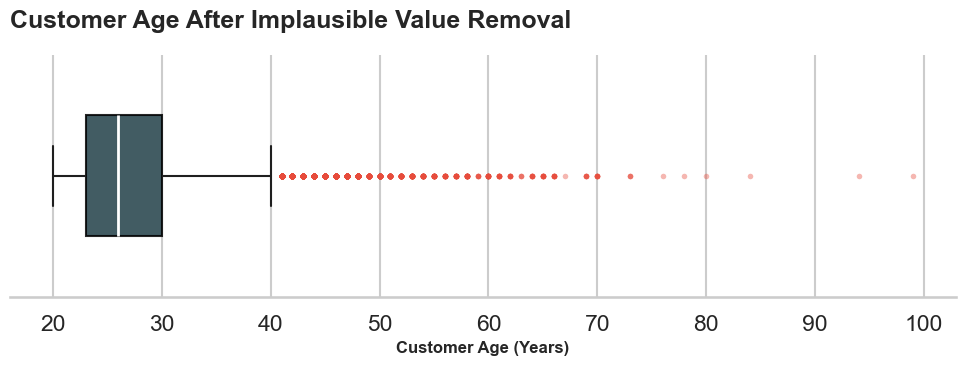

In [36]:
plot_professional_boxplot(data, 'customer_age', title="Customer Age After Implausible Value Removal", xlabel="Customer Age (Years)")

##### customer_income

Customer income exhibits substantial right skew consistent with real-world earnings distributions. Rather than removing high-income observations, which represent legitimate population variability, a logarithmic transformation was applied to stabilize variance and improve model compatibility.

In [37]:
# Call the currency conversion function and correct the dataset
data['customer_income'] = currency_to_float(data['customer_income'])

# Now that we are in numerical form, we can analyze the series using the iqr_outliers function
iqr_outliers(data, 'customer_income')


AttributeError: Can only use .str accessor with string values, not integer

In [ ]:
# This is a check that the upper echelon of income earners are not outliers but rather the product of normally observed income stratification.
data['customer_income'].describe(percentiles=[.95, .99, .999]).apply(lambda x: format(x, 'f'))

In [ ]:
# Apply a log-normal transformation to heavy right-tailed data and save to new column
data['log_customer_income'] = np.log1p(data['customer_income'])

In [ ]:
plot_professional_boxplot(data, column="customer_income", title="Customer Income (Raw Distribution)", divisor=1000, xlabel="Income (Thousands of Euros)", is_currency=True)
plot_professional_boxplot(data, column="log_customer_income", title="Effect of Log Transformation on Income Distribution", xlabel="Log(Customer Income)")

##### employment_duration

One observation was identified as implausible, reflecting an employment tenure of 123 years. This record was removed as it likely represents a data entry error rather than a valid observation. The remaining outliers were retained because, although uncommon, they fall within a plausible range of employment durations. After cleaning, the distribution of this feature remains right-skewed.

In [ ]:
# Function that reveals outliers 
tenure_outlier = iqr_outliers(data, 'employment_duration')
tenure_outlier['employment_duration'].max()

# Drop the most implausible data points. 
data = data[data['employment_duration'] <= 100]


In [ ]:
plot_professional_boxplot(data, 'employment_duration', title="Employment Duration After Implausible Value Removal", xlabel="Employment Duration (Years)")


##### loan_intent

In [ ]:
# The only objects I wanted to modify were the column values.  This is purely an aesthetic choice so that if I should need to visualize this feature the labeling will flow through nicely.  

intent_replace = {
    'EDUCATION':'Education',
    'MEDICAL':'Medical',
    'VENTURE':'Venture',
    'PERSONAL':'Personal',
    'DEBTCONSOLIDATION':'Debt Consolidation',
    'HOMEIMPROVEMENT':'Home Improvement',
}

data['loan_intent'].replace(intent_replace)

##### loan_amnt

Formal outlier tests such as Grubbs’ test were considered but ultimately rejected due to violations of normality assumptions and evidence suggesting mixed data-generating processes. Instead, distributional diagnostics using log-transformed values and percentile gap analysis were conducted to evaluate extreme observations.

This analysis revealed two loan amounts — 1,000,000 and 3,500,000 — that represent a substantial departure from the remainder of the distribution. To further investigate, an empirical cumulative distribution function (eCDF) plot was examined on a log₁₀ scale. The eCDF displayed a sharp vertical jump between the third and fifth orders of magnitude, and then a flat leveling off toward the right-most portion of the curve.  What is shown indicates a discontinuity inconsistent with the otherwise smooth distribution of loan values.

Such behavior suggests these observations likely originate from a different lending population, data entry irregularities, or an alternative product process rather than the same generating mechanism as the majority of records. Based on this evidence, these values were classified as noise rather than meaningful signal and were removed prior to downstream modeling.

In [ ]:
# loan_amnt formatting needs to be adjusted into numeric from string for analysis. 
if not pd.api.types.is_numeric_dtype(data['loan_amnt']):
    data['loan_amnt'] = currency_to_float(data['loan_amnt'])

loan_amnt_outliers = iqr_outliers(data, 'loan_amnt')
loan_outlier_min = loan_amnt_outliers['loan_amnt'].min(); print(f'Outlier Min: {loan_outlier_min}')
loan_outlier_max = loan_amnt_outliers['loan_amnt'].max(); print(f'Outlier Max: {loan_outlier_max}')

In [ ]:
# The outliers were very spread apart.  On the top boxplot take note of the two datapoints deep into the right skew.  Given the context of this being financial data, I ran a eCDF plot to infer on tail behavior.  
plot_professional_boxplot(data, column="loan_amnt", title="Loan Amount Distribution (Linear)", is_currency=True)
plot_professional_ecdf(
    data, 
    column='loan_amnt', 
    title="", 
    log_scale=True, 
    divisor=1000, 
    is_currency=True,
    xlabel="Loan Amount (Log Scale, k€)"
)

In [ ]:
# Drop the outliers from the dataset
data = data[data['loan_amnt'] < 900000]

##### loan_int_rate

Outliers detected via IQR were retained because:
- values fall within realistic lending ranges
- represent <0.3% of observations
- likely reflect legitimate high-risk loans

In [ ]:
loan_int_rate_outlier = iqr_outliers(data, 'loan_int_rate')
rates = loan_int_rate_outlier['loan_int_rate']

# Seventy obervations so I created a bin/count to display them.
bins = np.arange(20.0, rates.max() + 0.5, 0.5)
binned_rates = pd.cut(rates, bins=bins)
binned_counts = binned_rates.value_counts().sort_index()
print(binned_counts)


In [ ]:
plot_professional_boxplot(data, column="loan_int_rate", title="Distribution of Loan Interest Rates", xlabel="Interest Rate (%)", is_currency=False)

# ANALYST NOTE: No abnormal interest rates detected.

##### cred_hist_length

We will keep the values as-is in the dataset.  None of the outliers are implausible and within a tolerant levels.  As would be expected, the credit history values mirror typical natural phenomena like life expectencies.  

In [ ]:
plot_professional_boxplot(data, column="cred_hist_length", title="Credit History Length: Distribution Analysis", xlabel="Years of Credit History", is_currency=False)

# ANALYST VERIFICATION: IQR detected outliers, but values are logically 
# plausible for credit history. No removal required.

#### Encoding categoricals

In [ ]:
# Encode our dependent variable
data["default_flag"] = data["Current_loan_status"].map({
    "DEFAULT": 1,
    "NO DEFAULT": 0
})


# Encode missing as its own state
# I do not want to toss this column completely until I have justifiable reasoning for doing so.  
# Instead, I encoded it into separate buckets for analysis downstream. 1-previously defaulted, 0-no prior default, -1-no history/unknown. 
data['historical_default'] = (
    data['historical_default']
        .map({'Y': 1, 'N': 0})
        .fillna(-1)
        .astype(int)
)

# This encodes the loan_grade series.  I will require this to produce feature engineering downstream. 

# Map the grades to codes
grade_map = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7
}
# Overwrite grades with codes
data["loan_grade"] = data["loan_grade"].map(grade_map)
# Sanity check to make sure there were no grades missed. 
data["loan_grade"].isna().sum()



#### Feature creation:

Feature Engineering Rationale

Additional features were constructed to better represent borrower
affordability, financial experience, and employment stability.
These transformations reflect common credit-risk underwriting metrics.

In [ ]:
# Income-to-loan ratio
# Higher ratios indicate safer borrowers.  Lower ratios indicate riskier borrowers. 
data["income_loan_ratio"] = data["customer_income"] / data["loan_amnt"]

In [ ]:
# Loan Burden
# This is synonymous to Debt-to-Income calculations. 
data["loan_percent_income"] = data["loan_amnt"] / data["customer_income"]

In [ ]:
# Employment stability metric
# Longer employment tenure, smaller the risk for default
data["employment_years"] = data["employment_duration"] / 12

In [ ]:
# Credit Experience vs Age metric
data["credit_age_ratio"] = data["cred_hist_length"] / data["customer_age"]

In [ ]:
# Interaction effect of Interest Rate vs loan grade. 
data["rate_per_grade"] = data["loan_int_rate"] / data["loan_grade"]

## Exploratory Data Analysis

Section 4: DATA UNDERSTANDING & EXPLORATION (CLEANED DATA)
├── 4.1 Summary Statistics on Clean Data
│   ├── data.describe() - now meaningful without NaN clutter
│   ├── data.info() - final data types confirmed
│   └── Missing data check - should be ~0% (or documented exceptions)
├── 4.2 Univariate Analysis
│   ├── Distributions of key variables
│   ├── Histograms, box plots, density plots
│   ├── Identify remaining data quality issues
│   └── Document any surprising patterns
├── 4.3 Bivariate Analysis
│   ├── Relationship between features and target
│   ├── Correlation analysis
│   ├── Chi-square for categorical variables
│   ├── Information Value (IV) calculations
│   └── Feature importance indicators
├── 4.4 Multivariate Patterns
│   ├── Segment analysis (default rates by group)
│   ├── Geographic patterns
│   ├── Demographic patterns
│   └── Product/loan type patterns
└── 4.5 Key Insights & Observations
    ├── Summary of interesting patterns found
    ├── Features that strongly separate defaulters from non-defaulters
    ├── Segment performance differences
    └── Candidate features for engineering

Section 5: FEATURE ENGINEERING
├── 5.1 Feature Creation Strategy
│   ├── Domain-driven features (based on lending knowledge)
│   ├── Statistical features (derived from EDA insights in Section 4)
│   ├── Interaction features (identified from multivariate analysis)
│   └── Temporal features (if applicable)
├── 5.2 Feature Creation Execution
│   ├── Create each feature with clear business logic
│   ├── Validate feature creation (no NaN leakage, values in expected range)
│   └── Document feature definitions
├── 5.3 Feature Selection & Dimensionality Reduction
│   ├── Remove low-variance features
│   ├── Handle multicollinearity (VIF analysis)
│   ├── Calculate Information Value (IV) for each feature
│   ├── Domain expertise filtering
│   └── Document which features removed and why
└── 5.4 Feature Transformations
    ├── Scaling/normalization decisions
    ├── Log transformations for skewed distributions
    ├── Categorical encoding strategy
    └── Justification for each transformation

Section 6: TRAIN/VALIDATION/TEST SPLIT
├── 6.1 Data Splitting Strategy
│   ├── Temporal split (if time-series) or random stratified
│   ├── Ratios: Train/Val/Test percentages
│   ├── Stratification by target (handle class imbalance)
│   └── Random seed for reproducibility
├── 6.2 Class Imbalance Handling
│   ├── Analyze default rate in each split
│   ├── Strategy: Oversampling, undersampling, SMOTE, class weights
│   ├── Execute on training set only
│   └── Document approach and rationale
└── 6.3 Data Leakage Prevention
    ├── Confirm feature observation window ≤ outcome observation window
    ├── No post-default information in features
    └── Validation: Splits are truly independent

### Univariate Analysis

Overview — goals

Purpose: Understand each variable's distribution, quality, and modelling suitability.
Outputs: summary table(s), plots, missingness report, outlier list, transformation suggestions, short narrative conclusions.
Checklist — must-do steps

Inventory: get variable names, types, unique counts, sample values. Use df.dtypes, df.info(), df.head().
Missingness: percent missing per column and patterns. (visualize with heatmap/missingno)
Numeric summary: mean, median, std, min, max, IQR, skewness, kurtosis, count, missing%, unique (if low cardinality).
Categorical summary: frequency table, mode, top categories, missing%, unique count, rare-category threshold.
Visualize distributions: histogram with KDE, density plot, boxplot, violin plot.
Outliers: flag by IQR rule and z-score; list extreme cases and consider capping/winsorizing.
Normality checks: QQ-plot, Shapiro/Wilks or D’Agostino/K² tests; record p-values.
Transformations: try log, sqrt, Box-Cox (positive only), Yeo-Johnson (handles zeros/negatives); compare skewness after transform.
Binning: consider quantile or domain bins for heavy-tailed numeric features.
Encoding readiness: indicate which categorical vars need OneHotEncoder, TargetEncoder, or ordinal mapping.
Scale need: check scale ranges and decide on StandardScaler vs MinMaxScaler per model.
Text/datetime/boolean: for text show length distribution; for datetime extract year/month/day/hour; for boolean show proportion.
Document: short prose summary per variable — distribution shape, issues, transformation/encoding recommendations.
Export: save summary tables and plots (CSV, PNG, HTML) and notebook cells that reproduce results.


Quick reporting table (columns to produce for each variable)
var: variable name
type: inferred dtype
n: non-missing count
missing_pct: percent missing
unique: unique count
mean/median/std/IQR (numeric)
skew/kurtosis
top_values (categorical: top 3 with counts)
outlier_pct
recommended_action (keep/drop/transform/encode/bin/cap)
Concise Python snippets (pandas + seaborn + scipy)

Inventory & missing:
Numeric summary + skew/kurtosis:
Categorical summary:
Plot distribution + boxplot + QQ:
Outlier flags (IQR & z-score):
Transform and compare skew:
Interpretation rules (quick)

Skew > 1 or < -1: strongly skewed — consider transform or robust model/metrics.
High kurtosis (>3): heavy tails — expect outliers.
Missing > 30%: strong candidate for drop or special imputation; document business impact.
Low-cardinality numeric (<10 unique): treat as categorical or ordinal.
Categorical with many levels (>50 or high cardinality): use target/embedding encoding or frequency thresholding.
Deliverables to include in your notebook

Variable inventory table (first cell).
Missingness heatmap and missing-summary CSV.
For each numeric variable: histogram + boxplot + QQ + numeric row in summary table.
For each categorical variable: frequency bar or table and top_values.
Outliers.csv listing row ids and flagged variables.
Transformations tried summary and final recommended transformed variable.
A one-paragraph Conclusions section: immediate issues, features to engineer, features to drop, next steps.
If you want, I can:



In [ ]:
#data.describe()
data[["customer_age","customer_income","employment_duration","loan_int_rate","term_years","cred_hist_length"]].describe()



##### customer_age

The customer_age feature represents the age of borrowers in the dataset. Following the removal of extreme outliers during the cleaning phase, the values range from $20$ to $99$ years. The distribution is significantly right-skewed, characterized by a mean of $27.72$ and a median of $26.00$, resulting in a calculated skewness of $1.976$—indicating a highly skewed distribution. This concentration toward younger borrowers is expected in credit risk datasets, as younger individuals often seek entry-level credit products.The standard deviation is $6.214$, with the Interquartile Range (IQR) spanning $7$ years. The first quartile ($Q_1$) is $23$, while the third quartile ($Q_3$) is $30$, meaning the middle $50\%$ of our borrower base is aged between $23$ and $30$. Notably, $75\%$ of all borrowers are under the age of $30$, and the $95^{th}$ percentile is $40$. This indicates that less than $5\%$ of the dataset consists of borrowers older than $40$ years.Visual analysis via histogram and Kernel Density Estimate (KDE) confirms a heavy right-tail. The boxplot reinforces these findings, showing a high density of data points at the lower age range with a long trail of "plausible outliers" representing older, less frequent borrowers.

In [ ]:
print(data['customer_age'].describe())
print(f"Skewness: {data['customer_age'].skew()}")

In [ ]:
# Find quantile at the right-most whisker. 
fortieth = (data['customer_age'] <= 40).mean()*100
print(f'The approximal {fortieth:.2f} percentile occurs at age 40.')


In [ ]:
# boxplot
plot_professional_boxplot(data, 'customer_age')

In [ ]:
# Histogram
plot_professional_histogram(data, 'customer_age', kde=True)


Based on this information, I recommend two strategies for dealing with `customer_age`.  
1. Binning.
2. log transformation

In [ ]:
# Define bin edges and descriptive labels
age_bins = [20, 25, 30, 40, 100]  # 100 acts as the upper bound for 40+
age_labels = ['20-24', '25-29', '30-39', '40+']

# Create the new binned column
data['age_group'] = pd.cut(
    data['customer_age'], 
    bins=age_bins, 
    labels=age_labels, 
    right=False # Includes the left value, excludes the right ([20, 25))
)

# Verify the distribution
print("Age Group Distribution:")
print(data['age_group'].value_counts(normalize=True).sort_index() * 100)

In [ ]:
# Apply Log Transformation
# We use log1p (log of 1 + x) as a best practice, though np.log works fine since age > 0
data['customer_age_log'] = np.log(data['customer_age'])

# Compare Skewness
original_skew = data['customer_age'].skew()
transformed_skew = data['customer_age_log'].skew()

print(f"Original Skewness: {original_skew:.3f}")
print(f"Transformed Skewness: {transformed_skew:.3f}")

# Visualizing the "Before vs After"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['customer_age'], kde=True, ax=ax1, color='#1a434e')
ax1.set_title("Original Age (Right Skewed)")

sns.histplot(data['customer_age_log'], kde=True, ax=ax2, color='#e67e22') # Contrast color
ax2.set_title("Log-Transformed Age (Normalized)")

plt.show()

##### customer_income


The `customer_income` portion of the data was even more skewed than `customer_age` measuring 9.7557.  Before applying a logarithm to the data, I wanted to point out that the mean income for our borrowers was 65880--over 10000 euros above the median emphasizing the severaty of the skew.  The minimum income for this dataset was 4000 euroes.  The middle 50% of incomes fell between 38500 and 79200.  The lower 25% from 4000 to 38500.  The 95th percentile of incomes maxes out at 138000 and the 99th percentile at 225000.  There are 353 incomes in the top 1% of borrows.  Note that one standard devation around the median is outside of the datasets mininum.  The boxplots red dots sillustrate the distribution and the plausible outliers.  I see those as viable incomes and therefore find it unwise to reject them as outliers.  Instead, I will apply a logarithm to the data.  This puts equal weighting on all of the data points producing a normal distributed KDE.  

In [ ]:
# Converts to float from 
print(data['customer_income'].describe().apply(lambda x: format(x, 'f')))
print(f"Skewness: {data['customer_income'].skew()}")

In [ ]:
# Find quantile at the right-most whisker. 
#fortieth = (data['customer_age'] <= 40).mean()*100
data['customer_income'].quantile(0.95)
top_1_percent = data[data['customer_income'] >= data['customer_income'].quantile(0.99)]
top_1_percent['customer_income']
#print(f'The approximal {fortieth:.2f} percentile occurs at age 40.')

In [ ]:
data['customer_income']

plot_professional_boxplot(data, column="customer_income")

In [ ]:
# Histogram
plot_professional_histogram(data, 'customer_income', kde=True)

In [ ]:
# Define bin edges and descriptive labels
income_bins = [0, 35000, 60000, 100000, np.inf]
income_labels = ['Low (<35k)', 'Mid-Low (35k-60k)', 'Mid-High (60k-100k)', 'High (100k+)']

# Create the new binned column
data['income_group'] = pd.cut(
    data['customer_income'], 
    bins=income_bins, 
    labels=income_labels, 
    right=False # Includes the left value, excludes the right ([20, 25))
)

# Verify the distribution
print("Income Group Distribution:")
print(data['income_group'].value_counts(normalize=True).sort_index() * 100)

In [ ]:
# Apply Log Transformation
# We use log1p (log of 1 + x) as a best practice, though np.log works fine since age > 0
data['customer_income_log'] = np.log(data['customer_income'])

# Compare Skewness
original_skew = data['customer_income'].skew()
transformed_skew = data['customer_income_log'].skew()

print(f"Original Skewness: {original_skew:.3f}")
print(f"Transformed Skewness: {transformed_skew:.3f}")

# Visualizing the "Before vs After"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['customer_income'], kde=True, ax=ax1, color='#1a434e')
ax1.set_title("Original Income (Right Skewed)")

sns.histplot(data['customer_income_log'], kde=True, ax=ax2, color='#e67e22') # Contrast color
ax2.set_title("Log-Transformed Income (Normalized)")

plt.show()

##### SomeFeature

##### SomeFeature

##### SomeFeature

##### SomeFeature


##### SomeFeature

In [ ]:
# The Target Variable:  Current_loan_status
plot_target_distribution(data, 'Current_loan_status')

###### Categorical & Ordinal Features

In [ ]:
plot_professional_default_rate(data, "home_ownership")
plot_professional_default_rate(data, "loan_intent")
plot_professional_default_rate(data, "loan_grade")
plot_professional_default_rate(data, "historical_default")


###### Continuous Financials

In [ ]:
#plot_professional_default_rate(data, "customer_income")
#plot_professional_default_rate(data, "loan_amnt")
#plot_professional_default_rate(data, "loan_int_rate")
#plot_professional_default_rate(data, "loan_percent_income")

In [ ]:
# Example for Income
data['income_bin'] = pd.qcut(data['customer_income'], q=10, duplicates='drop')
plot_professional_default_rate(data, 'income_bin', title="Default Rate by Income Decile")

cont_features = ['customer_income', 'loan_amnt', 'loan_int_rate']

for col in cont_features:
    # Use the Histogram/Boxplot combo function here
    plot_univariate_continuous(data, col, f"Distribution of {col.replace('_', ' ').title()}")

###### Discrete Features

In [ ]:
plot_professional_default_rate(data, "customer_age")
plot_professional_default_rate(data, "employment_duration")
plot_professional_default_rate(data, "cred_hist_length")


##### Bivariate Analysis

##### Multivariate Analysis

In [ ]:
sns.pairplot(data)

##### Target Understanding of Baseline Risk

In [ ]:
# Compute baseline default rates.
default_rate = data["default_flag"].mean()
print(f"Overall Default Rate: {default_rate:.2%}")

In [ ]:
data["default_flag"].value_counts().plot(kind="bar")
plt.title("Default vs Non-Default Counts")
plt.show()

In [ ]:
default_rate_by_feature(data, "home_ownership")

In [ ]:
default_rate_by_feature(data, "loan_intent")

In [ ]:
default_rate_by_feature(data, "historical_default")

In [ ]:
sns.boxplot(x="default_flag", y="loan_int_rate", data=data)
plt.show()

In [ ]:
sns.boxplot(
    x="default_flag",
    y="loan_percent_income",
    data=data
)
plt.show()

In [ ]:
sns.boxplot(x="default_flag", y="customer_income", data=data)
plt.yscale("log")
plt.show()

In [ ]:
data["rate_bin"] = pd.qcut(data["loan_int_rate"], 10)

default_rate_by_feature(data, "rate_bin")

In [ ]:
import matplotlib.ticker as mtick

def plot_professional_default_rate(df, feature, title=None):
    # Calculate rates
    summary = df.groupby(feature)["Current_loan_status"].value_counts(normalize=True).unstack()["DEFAULT"]
    summary = summary.sort_values(ascending=False)
    
    # 1. Setup Figure
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    # 2. Use a sophisticated color palette (e.g., 'mako' or custom hex)
    colors = ['#1a434e' if (x < summary.max()) else '#e74c3c' for x in summary]
    
    sns.barplot(x=summary.index, y=summary.values, palette=colors, ax=ax)
    
    # 3. Enhance Typography and Labels
    ax.set_title(title or f"Default Risk by {feature.replace('_', ' ').title()}", 
                 fontsize=18, pad=20, fontweight='bold', loc='left')
    ax.set_ylabel("Probability of Default", fontsize=12, fontweight='bold')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    
    # 4. Format Y-axis as Percentage
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # 5. Remove "Chart Junk" (Spines)
    sns.despine(left=True, bottom=False)
    
    # 6. Add Data Labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_professional_default_rate(data, 'customer_income', title=None)

In [ ]:
plot_professional_default_rate(data, 'customer_age', title=None)

In [ ]:
data.columns

##### Univariate Risk Analysis

##### Affordability & Financial Stress Analysis

##### Credit history & Behavior Signals

##### Interaction Exploration

##### Data Quality Checks for Modeling

##### Hypothesis Summary

## Modeling Pipeline

Train/test split

Preprocessing pipeline

Multiple models

## Model Evaluation

Compare models

Select champion

## Model Interpretation

Key drivers of default

Explain results clearly

## Business Recommendations

Risk segments

Lending strategy suggestions

## Conclusion

Limitations

Future improvements